#### LangGraphによるエージェントの構築

LangGraphは、LLMアプリを ステートグラフ という「状態を持つグラフ」で作成。複雑な動きを作れる。

例えば：チェーンみたいな一方向だけでなくループや分岐も作れる
　　　　ノード間で共有できるステート情報を持てる
　　　　フローの途中で人が介入できるノードの途中で、
　　　　次のアクションを決められる

LangGraphの構成要素は以下。

ステートグラフ（State Graph）：グラフとステートが入る入れ物。
グラフ（Graph）：処理の流れ。
ノード（Node）：グラフ内の各処理ステップ（コンポーネント）。
エッジ（Edge）：ノード間の接続。
ステート（State）：ノード間で受け渡すデータ。

◆LangGraphの基本・・・ノード1つの、シンプルなチャットボット

　　開始　→　Nodeチャットボット　→　終了


◆準備

In [1]:
# 必要なモジュールをインポート
import os
from dotenv import load_dotenv
from langchain_openai import ChatOpenAI

# 環境変数の読み込み
load_dotenv("../.env")
os.environ['OPENAI_API_KEY'] = os.environ['API_KEY']

# モデル名
MODEL_NAME = "gpt-4o-mini"


◆ ステートグラフの作成

ステートを定義し、ステートグラフ　をつくって状態を保持させる

In [ ]:
from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph import StateGraph
from langgraph.graph.message import add_messages

# ステートの定義
class State(TypedDict):   #TypedDict を継承したクラス
    # データを保存する属性
    messages: Annotated[list, add_messages] 
    #通常上書きのところ、add_messages 関数で追記に変えている

# ステートグラフの作成
graph_builder = StateGraph(State)  #グラフをつくる入れ物。

◆ グラフの作成
チャットボットノード1つだけはいってる

In [ ]:
# 言語モデルの定義
llm = ChatOpenAI(model_name=MODEL_NAME)

# ”チャットボットノード“　の作成
def chatbot(state: State):
    return {"messages": [llm.invoke(state["messages"])]}

# グラフにチャットボットノードを追加（いっこ足しただけ
graph_builder.add_node("chatbot", chatbot)

# 開始ノードの指定（もちろん上記の一個。複数ある場合ははじめに動かすほう）
graph_builder.set_entry_point("chatbot")
# 終了ノードの指定（同様
graph_builder.set_finish_point("chatbot")

# 実行可能なステートグラフの作成
graph = graph_builder.compile() #ここでステートグラフをコンパイルしてる

◆ ステートグラフの可視化

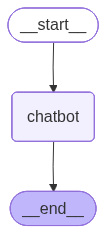

In [ ]:
# グラフの可視化　（絵が出るのね💦
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

◆ グラフの実行
messages 属性に、ユーザーからの質問（HumanMessage 型）を
要素として持つリストを渡してみる

In [7]:
# グラフの実行
response = graph.invoke(
    {"messages": [("user", "光の三原色は？")]}
    )

# 結果の表示
print(response)

{'messages': [HumanMessage(content='光の三原色は？', additional_kwargs={}, response_metadata={}, id='64c53b06-a61f-4d28-9917-18cd97a88b40'), AIMessage(content='光の三原色は、赤（Red）、緑（Green）、青（Blue）です。これらの色を組み合わせることで、さまざまな色を作り出すことができます。この方式は、RGBカラーシステムとして知られ、ディスプレイや照明などの分野で広く使用されています。', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 77, 'prompt_tokens': 14, 'total_tokens': 91, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_29330a9688', 'finish_reason': 'stop', 'logprobs': None}, id='run-e6271b13-1c44-496e-ae85-a78a2dd2a6f1-0', usage_metadata={'input_tokens': 14, 'output_tokens': 77, 'total_tokens': 91, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}})]}


ノードの実行結果が State の add_messages 関数で
処理されたことにより、結果は [HumanMessage, AIMessage] の
リストとなります。

→　言語モデルからの回答のみを表示
messages リストの末尾の1要素を -1 で取り出すとそうなる

In [8]:
# 言語モデルからの回答のみを表示
print(response["messages"][-1].content)

光の三原色は、赤（Red）、緑（Green）、青（Blue）です。これらの色を組み合わせることで、さまざまな色を作り出すことができます。この方式は、RGBカラーシステムとして知られ、ディスプレイや照明などの分野で広く使用されています。


◆◆チャットボットシステムの作成

In [9]:
# グラフの実行と結果の表示
def stream_graph_updates(user_input: str):
    # 結果をストリーミングで得る
    events = graph.stream({"messages": [("user", user_input)]})
    for event in events:
        for value in event.values():
            print("回答:", value["messages"][-1].content, flush=True)

# チャットボットのループ
while True:
    user_input = input("質問:")
    if user_input.strip()=="":
        print("ありがとうございました!")
        break
    print("質問:", user_input, flush=True)
    stream_graph_updates(user_input)

質問: こんにちは
回答: こんにちは！どのようにお手伝いできますか？
質問: 光の三原色とは？
回答: 光の三原色とは、光の色を表現するための基本的な3つの色のことを指します。これらは赤（Red）、緑（Green）、青（Blue）の3色で、一般的には「RGB」と呼ばれます。これらの色を異なる強さで組み合わせることで、さまざまな色を作り出すことができます。

光の三原色は、デジタル画像やテレビ、コンピュータモニターなどの表示技術において重要な役割を果たしています。例えば、赤、緑、青の光をそれぞれ異なる強さで混ぜることで、白色光を作ることができます。これは加法混色と呼ばれる現象で、光の色を混ぜる方法の一つです。

これに対して、絵の具やインクなどの物質の色を混ぜる場合には、減法混色が使われます。この場合は、シアン、マゼンタ、イエロー（CMY）が基本的な色とされます。
ありがとうございました!


グラフは記憶を持たない！ので、会話は毎回リセットされる。
◆記憶を持たせる

In [11]:
from langgraph.checkpoint.memory import MemorySaver

# チェックポインタの作成　メモリに状態を保存してくれる
memory = MemorySaver()

# 記憶を持つ実行可能なステートグラフの作成
memory_graph = graph_builder.compile(checkpointer=memory)

※実際のアプリでは SqliteSaver などを使用してデータベースやストレージに状態を保存すると良い

In [12]:
# グラフの実行と結果の表示
def stream_graph_updates(user_input: str):
    events = memory_graph.stream(
        {"messages": [("user", user_input)]},
        {"configurable": {"thread_id": "1"}},
        stream_mode="values")
    # 結果をストリーミングで得る
    for event in events:
        print(event["messages"][-1].content, flush=True)

# チャットボットのループ
while True:
    user_input = input("質問:")
    if user_input.strip()=="":
        print("ありがとうございました!")
        break
    stream_graph_updates(user_input)

こんにちは
こんにちは！どういったことをお手伝いできますか？
今日の天気は？
申し訳ありませんが、リアルタイムの情報を提供することはできません。お住まいの地域の天気予報を確認するには、天気予報のウェブサイトやアプリをご利用ください。他にお手伝いできることがあれば教えてください！
ひとつ前に、何を確認した？
前の質問では、今日の天気について尋ねられました。天気に関する具体的な情報は提供できない旨をお伝えしました。他にお知りになりたいことがあれば、どうぞお知らせください！
ありがとうございました!


Next:ツール呼び出しエージェントの構築